# COF-Landscaper hybrid/HPC postprocessing

Run `cof-landscaper.py` with the companion JSON configuration locally or on an HPC system before using this notebook. The driver performs construction, MACE screening, candidate optimization, analysis, and simulated PXRD generation. This notebook supports interactive inspection and PXRD-guided refinement. 

In [1]:
import coflandscaper as cl

/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [2]:
COF_NAME = "TABQ-THA"
MODE = "both"

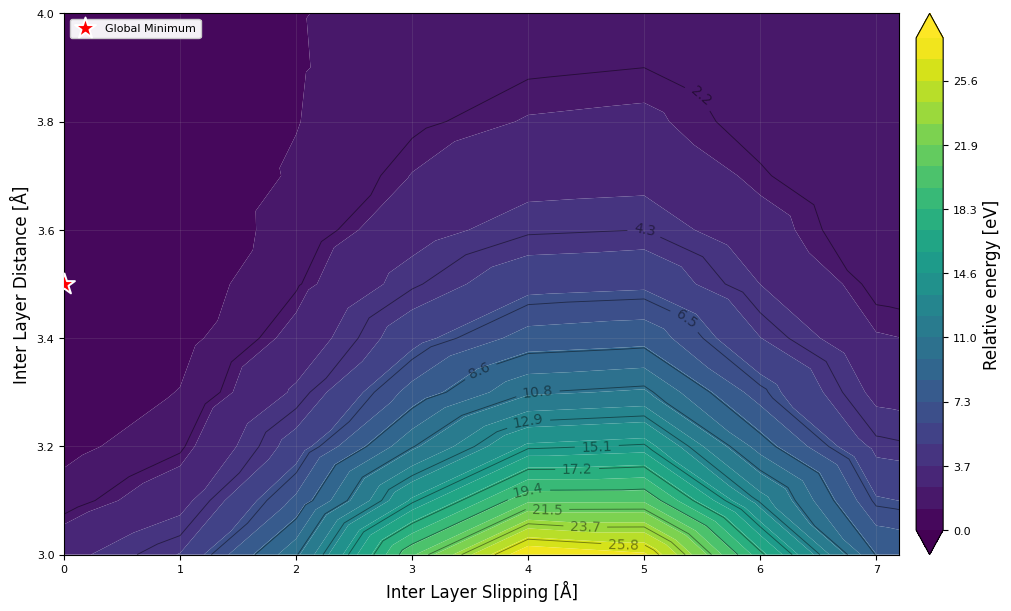

Saved: TABQ-THA/3_TABQ-THA_landscape/pes_TABQ-THA_serr.png


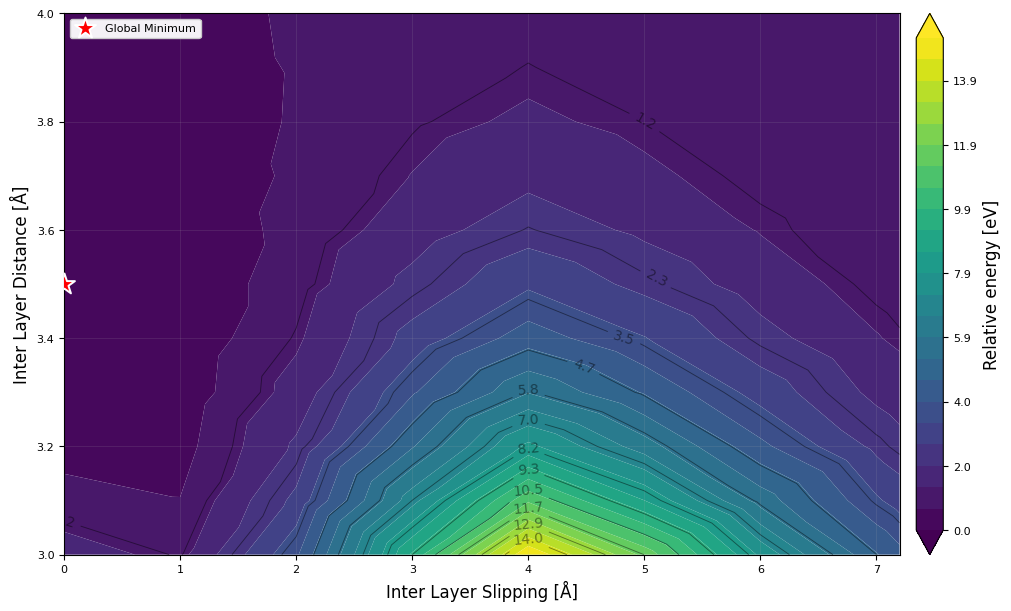

Saved: TABQ-THA/3_TABQ-THA_landscape/pes_TABQ-THA_incl.png


In [3]:
landscape = cl.Landscape()
landscape.run(cof_name=COF_NAME, mode=MODE, show=True)

### Analysis & Visualization

This step analyzes optimized structures by computing interlayer distance (ILD) and interlayer slipping (ILS) from the optimized structures, and writing a summary CSV for comparison across stacking configurations.

In addition, structures can be visualized using an interactive viewer.

In [4]:
# Defaults
analyzer = cl.AnalyzeStacking()
analyzer.analyze(cof_name=COF_NAME, mode=MODE)

Serrated:
 ILD (Å)  ILS (Å)  Erel (eV)
   3.35     7.36        0.9
   3.31     1.52        0.0
Inclined:
 ILD (Å)  ILS (Å)  Erel (eV)
   3.34     7.41        0.9
   3.32     1.55        0.0


In [ ]:
# Defaults
visualizer = cl.VisualizeCOF()
visualizer.visualize_cof(cof_name=COF_NAME, mode=MODE)

### Experimental PXRD comparison

Place exactly one experimental `.xy` file in `experimental_pxrd/`, or pass its path explicitly. The comparison generates one PDF per simulated structure in `pxrd_plots`.

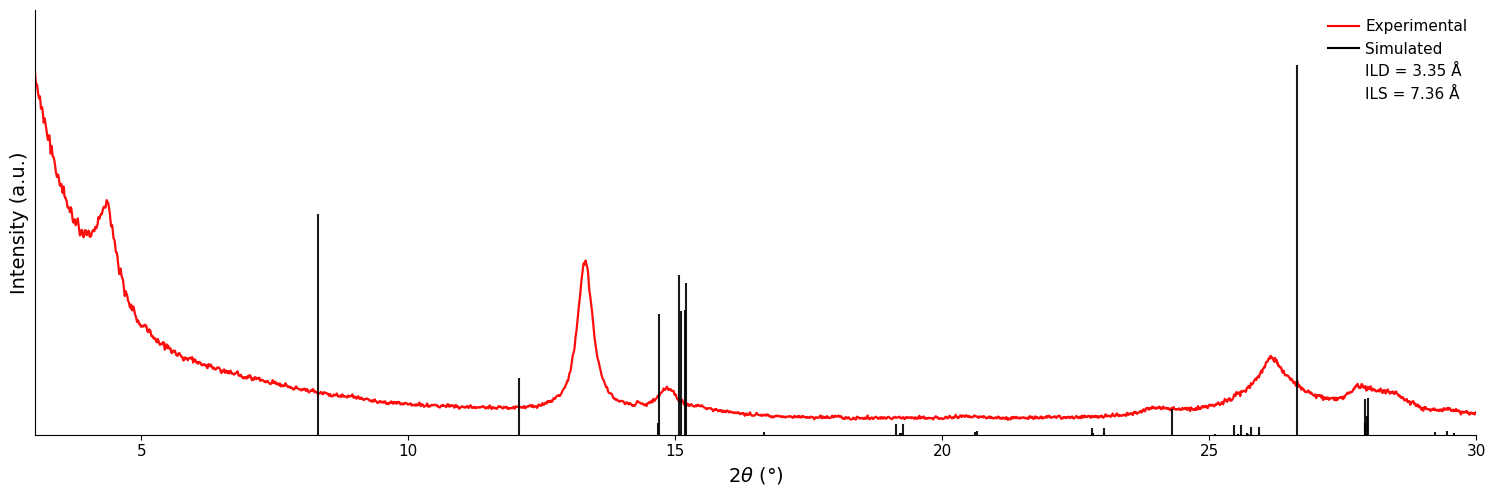

Plotted simulated and experimental PXRD pattern for TABQ-THA_z34_L072_serr.cif


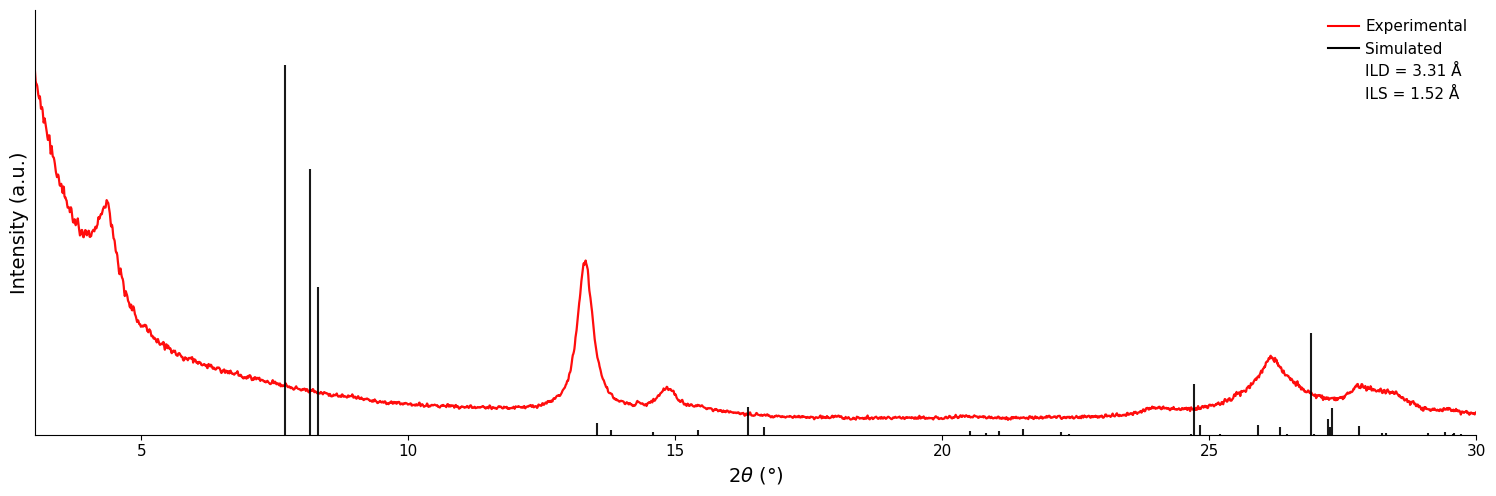

Plotted simulated and experimental PXRD pattern for TABQ-THA_z35_L000_serr.cif


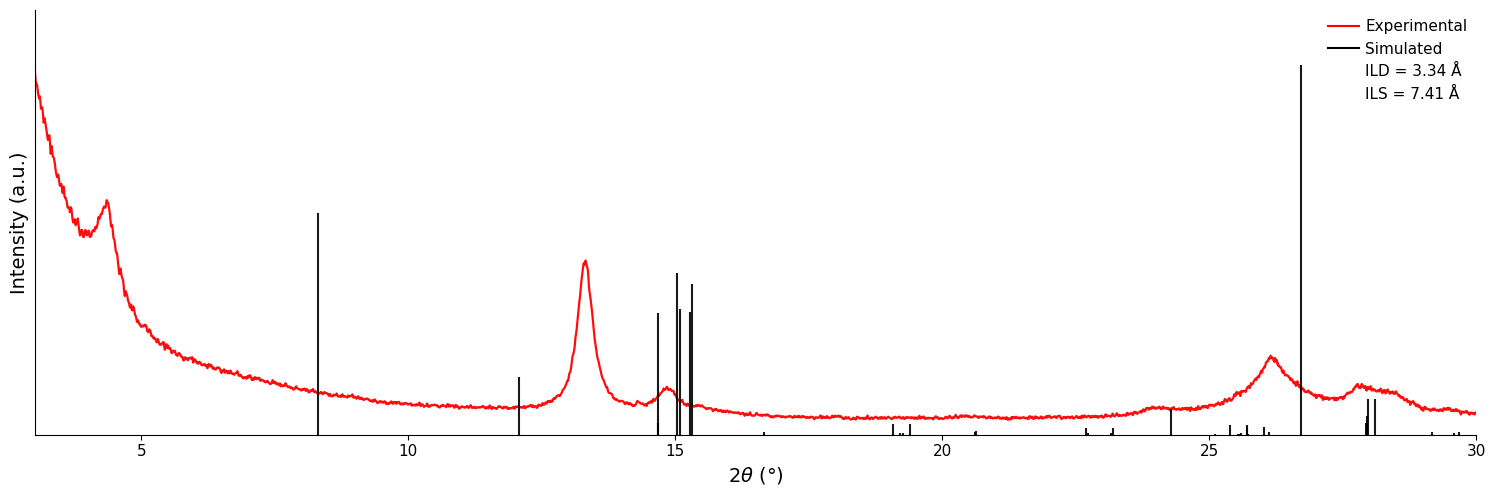

Plotted simulated and experimental PXRD pattern for TABQ-THA_z34_L072_incl.cif


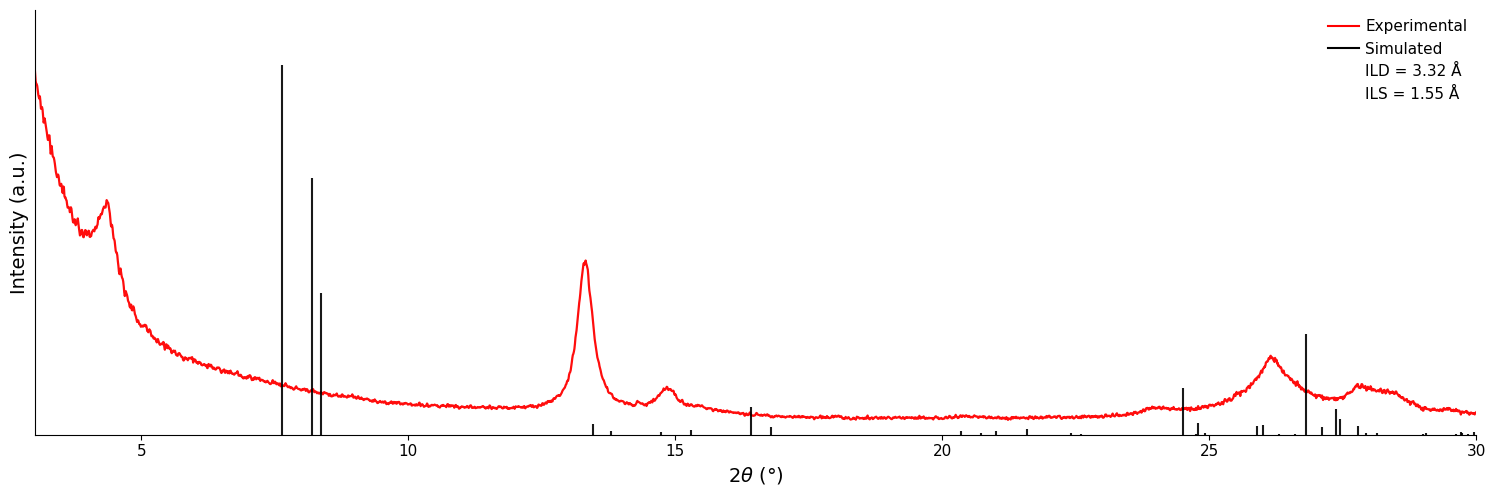

Plotted simulated and experimental PXRD pattern for TABQ-THA_z35_L000_incl.cif


['TABQ-THA/5_TABQ-THA_analysis/pxrd_plots/serr/TABQ-THA_z34_L072_serr.pdf',
 'TABQ-THA/5_TABQ-THA_analysis/pxrd_plots/serr/TABQ-THA_z35_L000_serr.pdf',
 'TABQ-THA/5_TABQ-THA_analysis/pxrd_plots/incl/TABQ-THA_z34_L072_incl.pdf',
 'TABQ-THA/5_TABQ-THA_analysis/pxrd_plots/incl/TABQ-THA_z35_L000_incl.pdf']

In [5]:
pxrd = cl.PXRD()
pxrd.plot_sim_vs_exp(
    cof_name=COF_NAME,
    mode=MODE,
    xlim=(3, 30),
)

## PXRD-guided refinement

The simulated and experimental PXRD patterns should first be inspected qualitatively. The refinement described below is intended for structures that already reproduce the experimental pattern reasonably well but show a **systematic offset in peak positions**. It is not intended to correct a stacking model whose simulated PXRD pattern is fundamentally inconsistent with experiment.

A consistent displacement of corresponding simulated and experimental reflections can indicate that the predicted structure is qualitatively correct while its unit-cell dimensions differ slightly from those of the experimental material. COF-Landscaper therefore provides a simple PXRD-guided refinement in which experimental diffraction peak positions are used to adjust the in-plane dimensions of the calculated structure. This follows the general principle of refining lattice dimensions against diffraction data.

If both serrated and inclined structures were evaluated above, first select the stacking mode(s) that provides the physically meaningful agreement with experiment. The comparison is performed within **user-defined 2θ regions**. Each region should contain an experimental feature and the corresponding simulated reflection that the user intends to compare.

A region is specified by its lower and upper 2θ limits:
Example:
```python

peak_regions = [
    (4.0, 5.5),
    (7.5, 9.0),
    (9.0, 10.5),
]

In [ ]:
MODE = "serr"

In [ ]:
peak_regions = [
    (4.0, 5.5),
    (7.5, 9),
    (9, 10.5),
    (12, 14),
    (15.5, 17.5),
    (24, 27.5),
]

pxrd.extract_peak_regions(
    cof_name=COF_NAME,
    mode=MODE,
    peak_regions=peak_regions,
)

### In-plane lattice scaling

The extracted experimental and simulated peak positions are used to estimate the in-plane lattice correction required to improve their agreement.

By default, all extracted peak regions are included (`scale_regions=None`). If some experimental features are broad, overlapping, or otherwise unsuitable for a reliable comparison, `scale_regions` can be used to restrict the scaling to selected regions.

For example, to use only regions 1, 2, and 4:

```python
scale_regions = [1, 2, 4]

In [ ]:
scaled_cifs = pxrd.generate_scaled_cif(
    cof_name=COF_NAME,
    mode=MODE,
    scale_regions=[1,2],
)

### Post-optimization

The PXRD-guided scaling changes the unit-cell dimensions geometrically. The scaled structure is therefore subsequently re-optimized with MACE while keeping the refined unit cell fixed, allowing the atomic coordinates to relax within the experimentally informed cell.

In [ ]:
postopt = cl.MaceOpt()
postopt.run_fixed(cof_name=COF_NAME, mode=MODE)

## Postopt analysis

Repeat structural and PXRD analysis against the post-optimized structures using `source="postopt"`.

In [ ]:
analyzer = cl.AnalyzeStacking()
analyzer.analyze(cof_name=COF_NAME, mode=MODE, source="postopt")

In [ ]:
pxrd.run(cof_name=COF_NAME, mode=MODE, source="postopt")
pxrd.extract_peaks(cof_name=COF_NAME, mode=MODE, source="postopt")
pxrd.extract_peak_regions(
    cof_name=COF_NAME,
    mode=MODE,
    peak_regions=peak_regions,
    source="postopt",
)

In [ ]:
pxrd.plot_sim_vs_exp(
    cof_name=COF_NAME,
    mode=MODE,
    source="postopt",
    xlim=(3.5, 30.0),
)

In [ ]:
visualizer = cl.VisualizeCOF()
visualizer.visualize_cof(
    cof_name=COF_NAME,
    mode=MODE,
    source="postopt",
)